# Prédiction du type de carburant (Fuel) Simulation de l'underfiting

## Import des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement des données

In [2]:
data = pd.read_csv('CarPriceDataset_Final.csv')
data.head()

,ID,Company,Model,Type,Fuel,Transmission,Engine,Mileage,Kms_driven,Buyers,Horsepower (kw),Year,Price (Lakhs)
0,1,Maruti,Alto,Hatchback,Petrol,Manual,796,19.7,45000,2,32,2010,1.2
1,2,Maruti,Wagon R,Hatchback,Petrol,Manual,998,20.5,40005,2,46,2011,3.0
2,3,Maruti,Wagon R,Hatchback,Petrol,Manual,998,20.5,40005,2,46,2018,4.0
3,4,Maruti,Ertiga,MUV,Petrol,Automatic,1462,18.5,28000,2,73,2012,5.1
4,5,Maruti,Ertiga,MUV,Petrol,Automatic,1462,18.5,40000,2,73,2012,4.0


In [3]:
data.shape

(150, 13)

In [4]:
data.columns

Index(['ID', 'Company', 'Model', 'Type', 'Fuel', 'Transmission', 'Engine',
       'Mileage ', 'Kms_driven', 'Buyers', 'Horsepower (kw)', 'Year',
       'Price (Lakhs)'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               150 non-null    int64  
 1   Company          150 non-null    object 
 2   Model            150 non-null    object 
 3   Type             150 non-null    object 
 4   Fuel             150 non-null    object 
 5   Transmission     150 non-null    object 
 6   Engine           150 non-null    int64  
 7   Mileage          147 non-null    float64
 8   Kms_driven       150 non-null    int64  
 9   Buyers           150 non-null    int64  
 10  Horsepower (kw)  150 non-null    int64  
 11  Year             150 non-null    int64  
 12  Price (Lakhs)    150 non-null    float64
dtypes: float64(2), int64(6), object(5)
memory usage: 15.4+ KB


In [6]:
data.isnull().sum()

ID                 0
Company            0
Model              0
Type               0
Fuel               0
Transmission       0
Engine             0
Mileage            3
Kms_driven         0
Buyers             0
Horsepower (kw)    0
Year               0
Price (Lakhs)      0
dtype: int64

## Nettoyage des données

In [7]:
data = data.drop(columns="ID")

In [8]:
data.duplicated().sum()

np.int64(1)

In [9]:
data.drop_duplicates(inplace=True)

In [10]:
data.rename(columns={'Mileage ': 'Mileage'}, inplace=True)

In [11]:
data[data["Mileage"].isna()]

,Company,Model,Type,Fuel,Transmission,Engine,Mileage,Kms_driven,Buyers,Horsepower (kw),Year,Price (Lakhs)
89,Jaguar,I Pace,SUV,Eletric,Automatic,0,NaN,130000,2,167,2019,80.0
115,Audi,e-tron,Sedan,Eletric,Automatic,0,NaN,30000,2,210,2014,70.0
116,Audi,e-tron,Sedan,Eletric,Automatic,0,NaN,50000,2,210,2017,27.0


In [12]:
# Remplacement des valeurs manquantes par la médiane de la colonne "Mileage" car la médiane est moins sensible aux valeurs extrêmes que la moyenne.
data["Mileage"] = data["Mileage"].fillna(data["Mileage"].median())

In [13]:
data.columns

Index(['Company', 'Model', 'Type', 'Fuel', 'Transmission', 'Engine', 'Mileage',
       'Kms_driven', 'Buyers', 'Horsepower (kw)', 'Year', 'Price (Lakhs)'],
      dtype='object')

In [14]:
data.Company.value_counts()

Company
 Audi          16
BMW            14
Maruti         11
 Tata          11
Hyundai        11
Ferrari        10
Lamborghini     9
Toyota          8
 Mahindra       8
Porsche         8
Jaguar          7
 Ford           7
 Honda          6
 Renault        6
 Kia            6
Rolls Royce     6
Land Rover      5
Name: count, dtype: int64

In [15]:
data.Company.unique()

array(['Maruti', ' Tata', ' Mahindra', ' Honda', 'Hyundai', ' Renault',
       'Ferrari', 'Land Rover', ' Kia', 'Toyota ', 'Jaguar', 'Porsche',
       ' Ford', ' Audi', 'BMW', 'Lamborghini', 'Rolls Royce'],
      dtype=object)

In [16]:
data.Company = data.Company.str.strip()

In [17]:
data.Company.unique()


array(['Maruti', 'Tata', 'Mahindra', 'Honda', 'Hyundai', 'Renault',
       'Ferrari', 'Land Rover', 'Kia', 'Toyota', 'Jaguar', 'Porsche',
       'Ford', 'Audi', 'BMW', 'Lamborghini', 'Rolls Royce'], dtype=object)

In [18]:
data.Type.value_counts()

Type
SUV            57
Sedan          36
Coupe          24
Hatchback      24
MUV             6
Convertible     2
Name: count, dtype: int64

In [19]:
data.Model.value_counts()

Model
Sonet         3
Ertiga        2
Wagon R       2
Bolero        2
Ciaz          2
             ..
Z4            1
Murcielago    1
Huracan       1
Ghost         1
Dawn          1
Name: count, Length: 99, dtype: int64

In [20]:
data.Transmission.value_counts()


Transmission
Automatic    128
Manual        19
Semi-Auto      2
Name: count, dtype: int64

In [21]:
data.Fuel.value_counts()

Fuel
Petrol      94
Diesel      46
Hybride      3
Eletric      3
Gas          2
Gasoline     1
Name: count, dtype: int64

### Nettoyage de la cible Fuel

Fuel contient des doublons sémantiques dus à des fautes de saisie :
Gas et Gasoline désignent la même chose que Petrol, et Hybride / Eletric désignent des
véhicules hybrides ou électriques que l'on regroupe sous une seule modalité Electrifie car ces deux catégories ne comptent que 3 véhicules chacune

In [22]:
fuel_1 = {
    "Gasoline": "Petrol",
    "Gas": "Petrol",
    "Hybride": "Electrifie",
    "Eletric": "Electrifie",
}
data["Fuel"] = data["Fuel"].replace(fuel_1)
data["Mileage"] = data["Mileage"].fillna(0)
data["Fuel"].value_counts()

Fuel
Petrol        97
Diesel        46
Electrifie     6
Name: count, dtype: int64

# Analyse exploratoire des données (EDA)

In [23]:
data.describe()

,Engine,Mileage,Kms_driven,Buyers,Horsepower (kw),Year,Price (Lakhs)
count,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,2582.583893,15.818792,36604.449664,2.322148,223.040268,2015.516779,62.415369
std,1689.071619,6.826050,19473.571446,0.700082,209.357475,3.380397,98.790787
min,0.000000,3.800000,3600.000000,2.000000,27.000000,2005.000000,0.800000
25%,1462.000000,10.600000,23452.000000,2.000000,74.000000,2014.000000,4.900000
50%,1997.000000,15.000000,36000.000000,2.000000,132.000000,2016.000000,20.000000
75%,2998.000000,20.040000,45000.000000,2.000000,322.000000,2018.000000,80.000000
max,6749.000000,47.450000,130000.000000,5.000000,985.000000,2021.000000,605.000000


In [24]:
data.describe(include='object')

,Company,Model,Type,Fuel,Transmission
count,149,149,149,149,149
unique,17,99,6,3,3
top,Audi,Sonet,SUV,Petrol,Automatic
freq,16,3,57,97,128


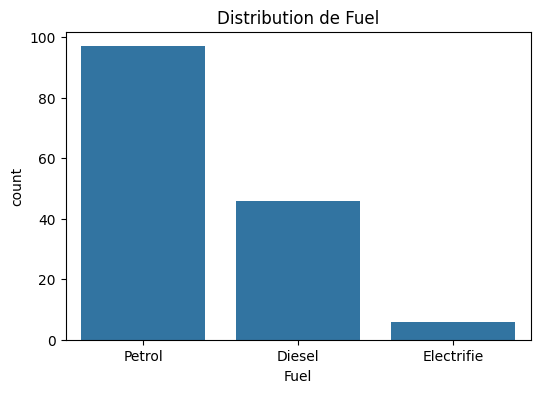

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x="Fuel")
plt.title("Distribution de Fuel")
plt.show()

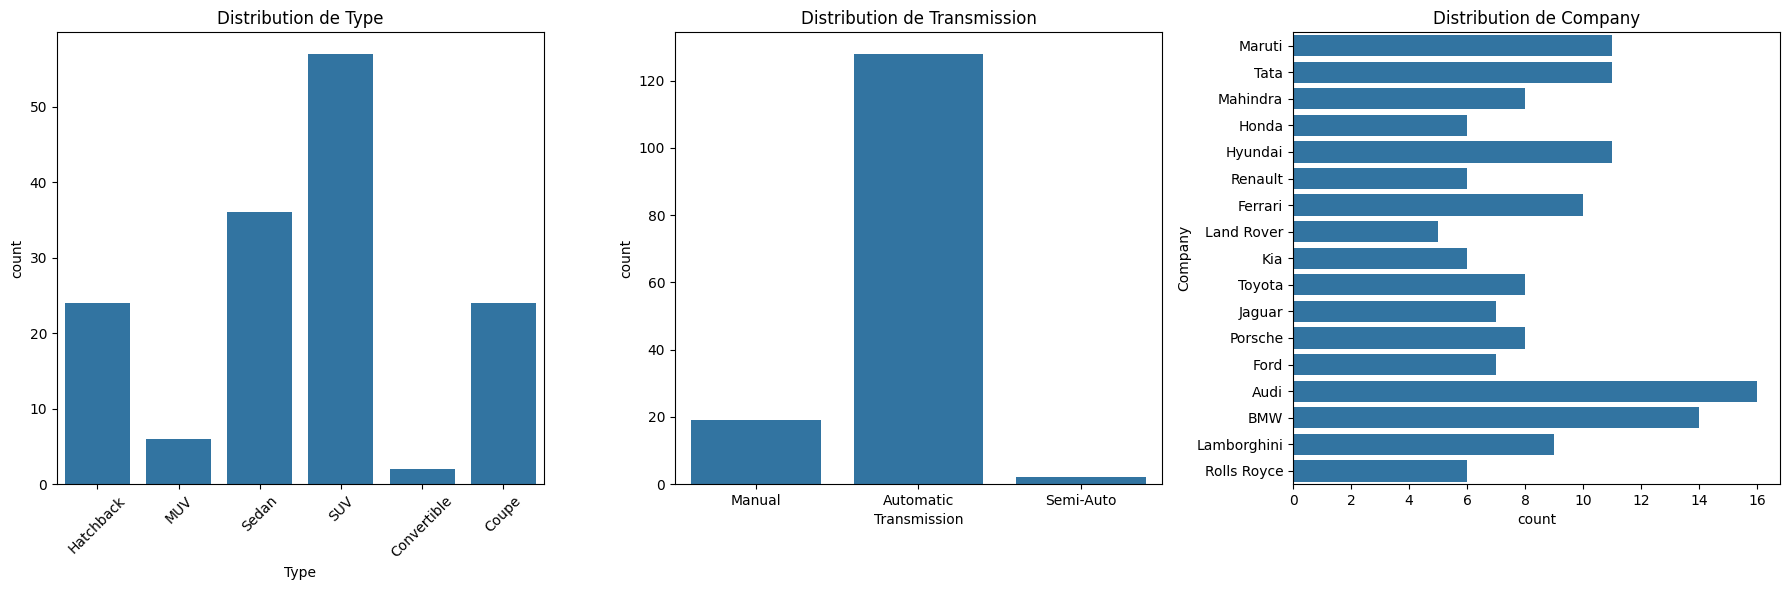

In [26]:
# Distribution de Type, Transmission et Company
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

sns.countplot(data=data, x="Type", ax=axes[0])
axes[0].set_title("Distribution de Type")
axes[0].tick_params(axis='x', rotation=45)
sns.countplot(data=data, x="Transmission", ax=axes[1])
axes[1].set_title("Distribution de Transmission")
sns.countplot(data=data, y="Company", ax=axes[2])
axes[2].set_title("Distribution de Company")

plt.tight_layout()
plt.show()


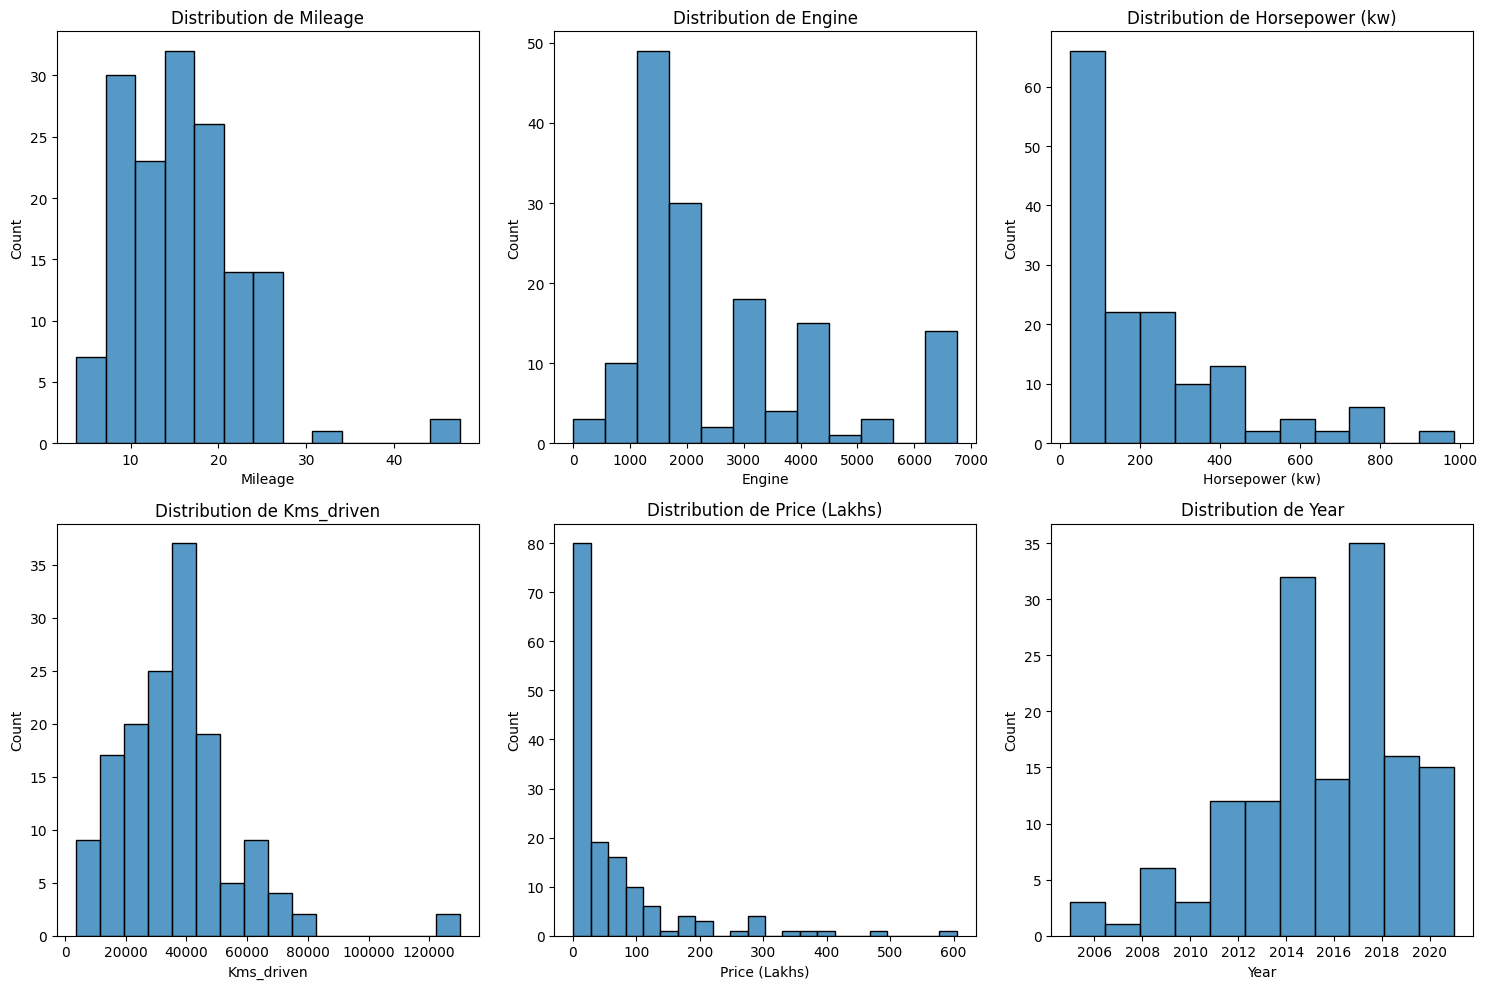

In [27]:
# Distribution des variables quantitatives
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

sns.histplot(data=data, x='Mileage', ax=axes[0, 0])
axes[0, 0].set_title('Distribution de Mileage')
sns.histplot(data=data, x='Engine', ax=axes[0, 1])
axes[0, 1].set_title('Distribution de Engine')
sns.histplot(data=data, x='Horsepower (kw)', ax=axes[0, 2])
axes[0, 2].set_title('Distribution de Horsepower (kw)')
sns.histplot(data=data, x='Kms_driven', ax=axes[1, 0])
axes[1, 0].set_title('Distribution de Kms_driven')
sns.histplot(data=data, x='Price (Lakhs)', ax=axes[1, 1])
axes[1, 1].set_title('Distribution de Price (Lakhs)')
sns.histplot(data=data, x='Year', ax=axes[1, 2])
axes[1, 2].set_title('Distribution de Year')

plt.tight_layout()
plt.show()

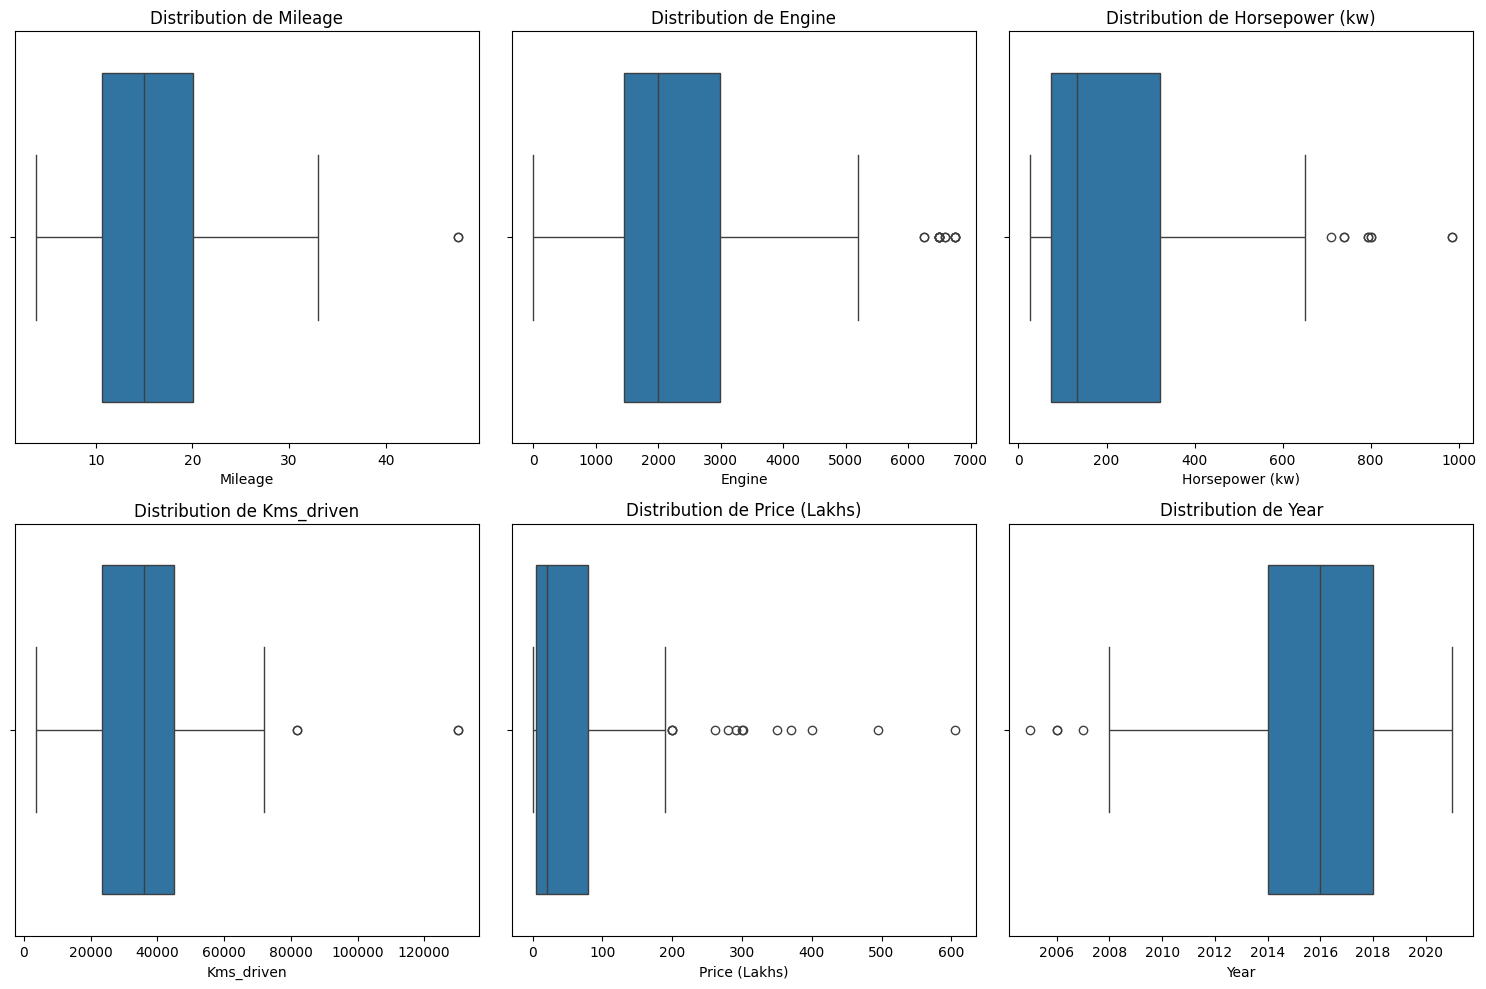

In [28]:
# Distribution des variables quantitatives
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

sns.boxplot(data=data, x='Mileage', ax=axes[0, 0])
axes[0, 0].set_title('Distribution de Mileage')
sns.boxplot(data=data, x='Engine', ax=axes[0, 1])
axes[0, 1].set_title('Distribution de Engine')
sns.boxplot(data=data, x='Horsepower (kw)', ax=axes[0, 2])
axes[0, 2].set_title('Distribution de Horsepower (kw)')
sns.boxplot(data=data, x='Kms_driven', ax=axes[1, 0])
axes[1, 0].set_title('Distribution de Kms_driven')
sns.boxplot(data=data, x='Price (Lakhs)', ax=axes[1, 1])
axes[1, 1].set_title('Distribution de Price (Lakhs)')
sns.boxplot(data=data, x='Year', ax=axes[1, 2])
axes[1, 2].set_title('Distribution de Year')

plt.tight_layout()
plt.show()

Les boxplots mettent en évidence la présence de valeurs élevées pour Engine, Horsepower (kw), Kms_driven et Price (Lakhs). Ces valeurs correspondent à des véhicules de luxe ou de sport et ne sont pas des erreurs. Étant donné la petite taille du jeu de données (149 lignes), nous préférons les conserver plutôt que les supprimer. Elles seront prises en compte lors du prétraitement grâce à une discrétisation en quantiles.

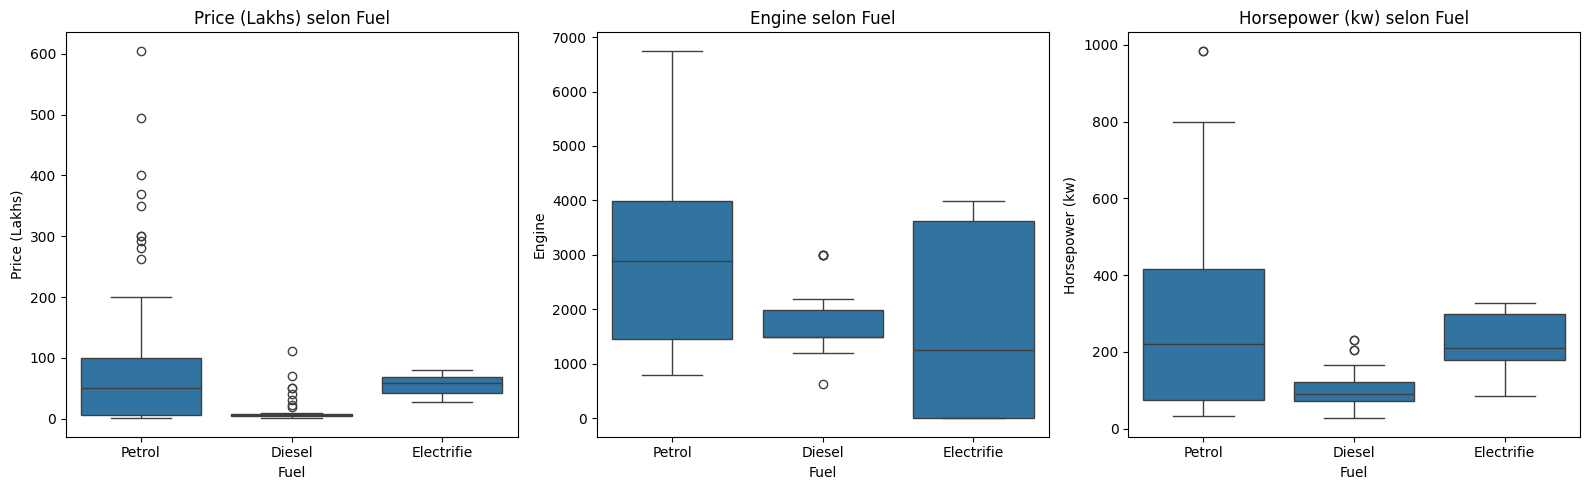

In [29]:
# Relation entre les variables explicatives et la cible
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=data, x="Fuel", y="Price (Lakhs)", ax=axes[0])
axes[0].set_title("Price (Lakhs) selon Fuel")
sns.boxplot(data=data, x="Fuel", y="Engine", ax=axes[1])
axes[1].set_title("Engine selon Fuel")
sns.boxplot(data=data, x="Fuel", y="Horsepower (kw)", ax=axes[2])
axes[2].set_title("Horsepower (kw) selon Fuel")

plt.tight_layout()
plt.show()

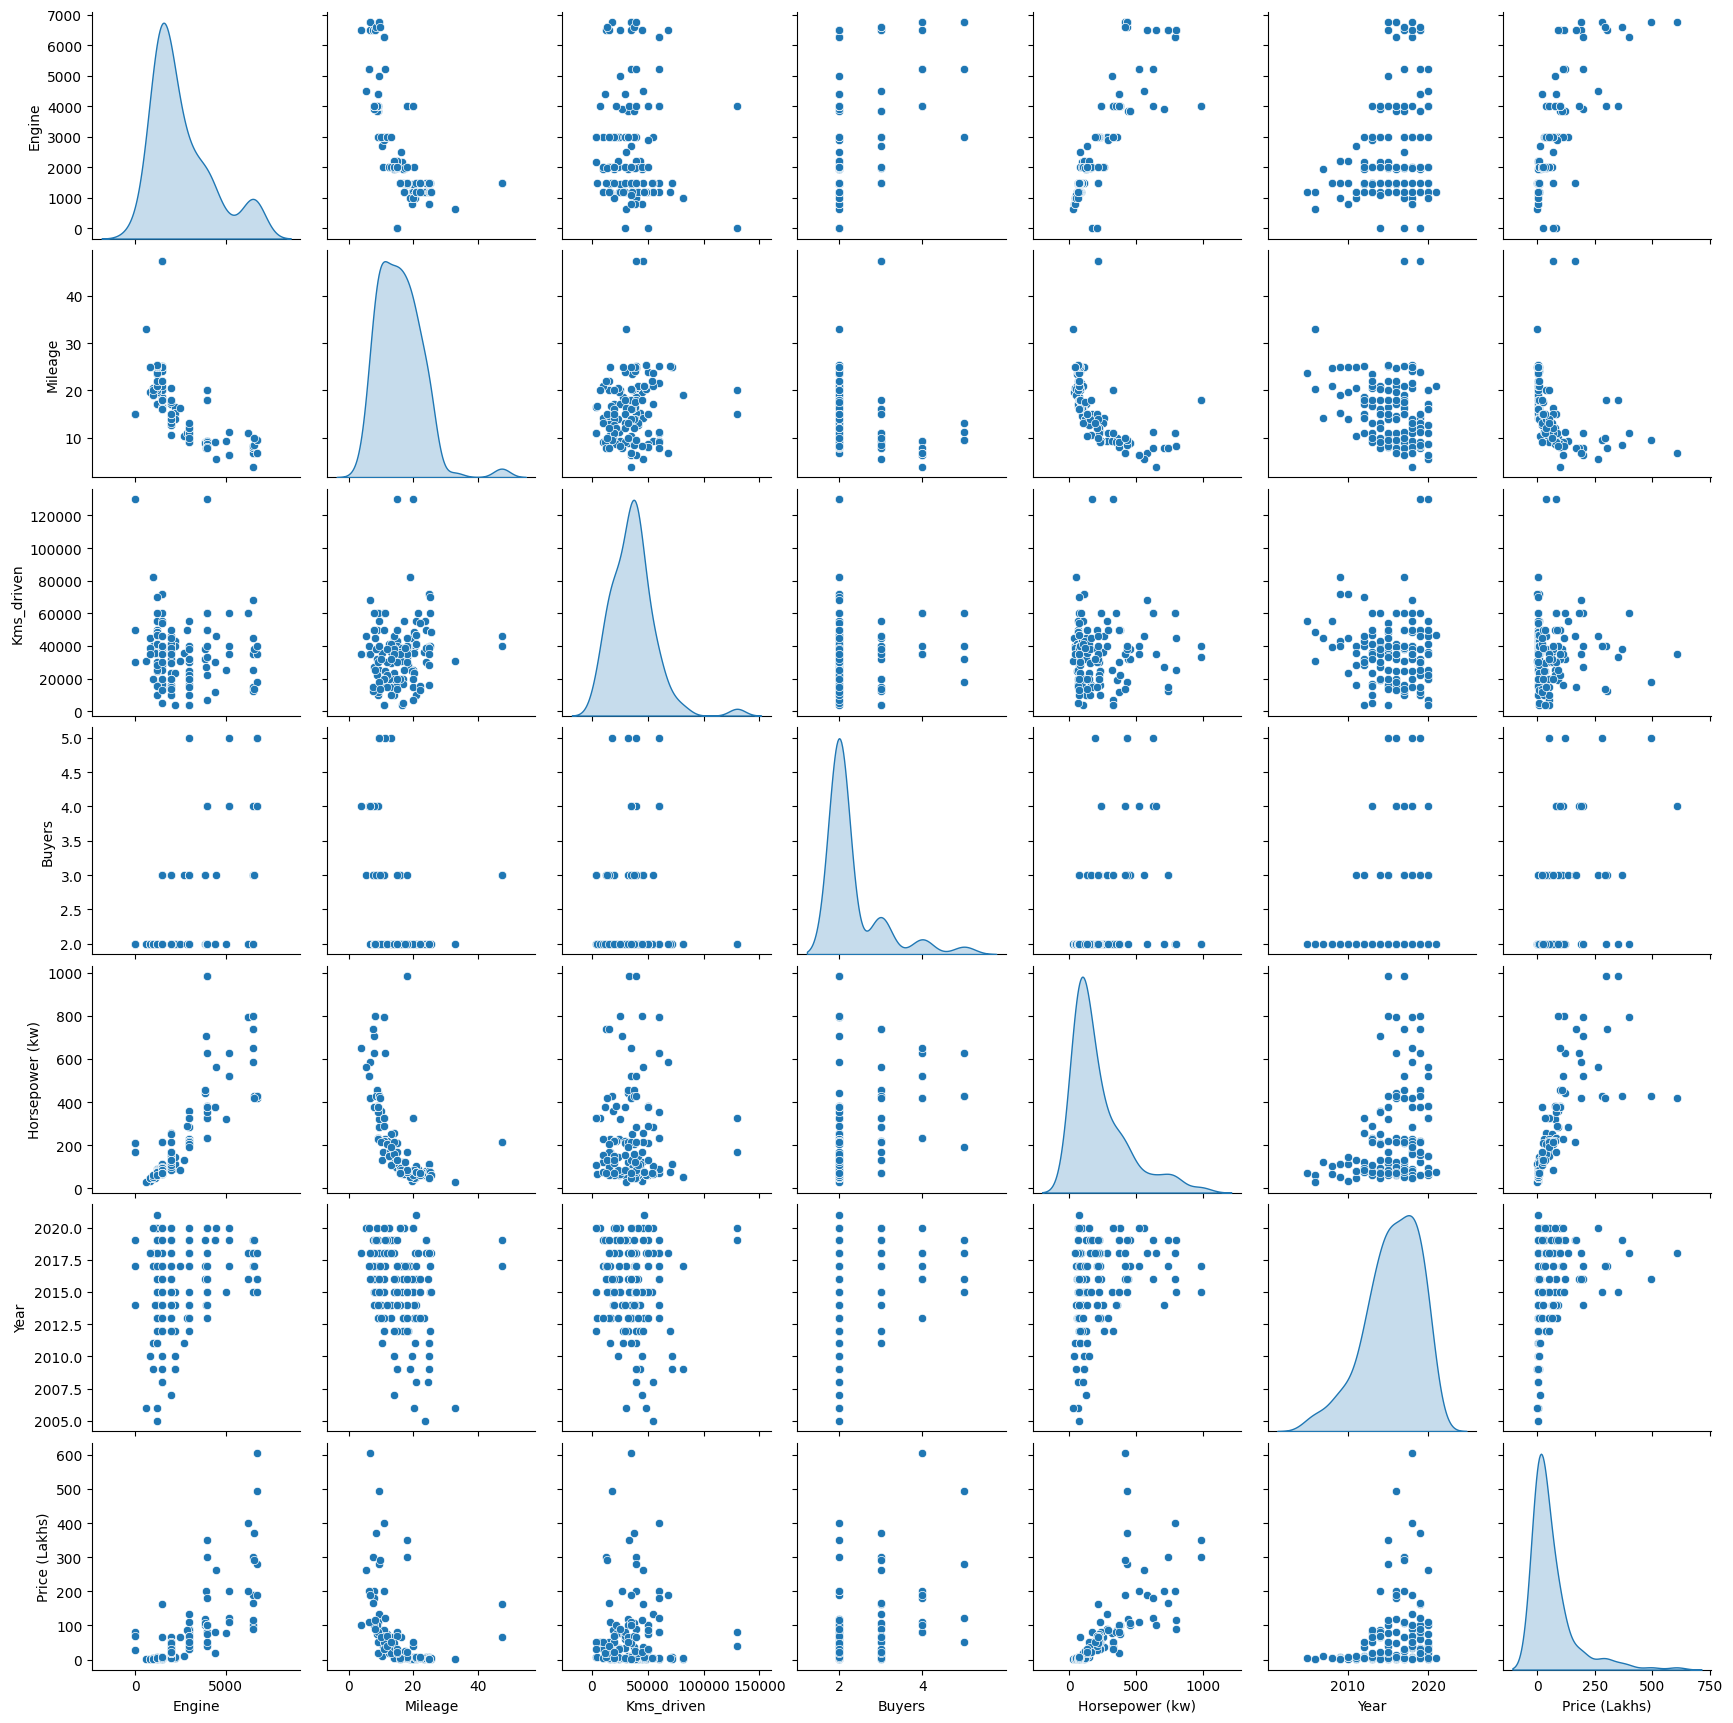

In [30]:
sns.pairplot(data, diag_kind='kde')

Pour notre modele d'underfiting avec Naive Bayes, nous n'allons pas selecrtionner Model puisqu'on a 99 modalites differentes pour 1 dataset de 149 lignes afin de mettre en evidence le sous apprentissage il sera utiliser pour le modele d'overfiting

# Split et entrainement

In [31]:
# Variables retenues pour le modèle Underfitting
cat_cols = ["Company", "Type", "Transmission"]
num_cols = ["Engine", "Mileage", "Kms_driven", "Horsepower (kw)", "Year", "Price (Lakhs)"]

X = data[cat_cols + num_cols].copy()
y = data["Fuel"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

X.head()

Dimensions de X : (149, 9)
Dimensions de y : (149,)


,Company,Type,Transmission,Engine,Mileage,Kms_driven,Horsepower (kw),Year,Price (Lakhs)
0,Maruti,Hatchback,Manual,796,19.7,45000,32,2010,1.2
1,Maruti,Hatchback,Manual,998,20.5,40005,46,2011,3.0
2,Maruti,Hatchback,Manual,998,20.5,40005,46,2018,4.0
3,Maruti,MUV,Automatic,1462,18.5,28000,73,2012,5.1
4,Maruti,MUV,Automatic,1462,18.5,40000,73,2012,4.0


## Séparation train / test

On sépare les données en un jeu d'entraînement (80%) et un jeu de test (20%), en stratifiant sur
Fuel pour que les 6 observations Electrifie soient réparties proportionnellement (sans
stratification, il serait possible qu'aucune observation Electrifie ne se retrouve dans le
test, rendant son évaluation impossible).

In [32]:
from sklearn.model_selection import train_test_split

y = data["Fuel"]
X = data.drop(columns=["Fuel"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape, " Test :", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

Train : (119, 11)  Test : (30, 11)
Fuel
Petrol        77
Diesel        37
Electrifie     5
Name: count, dtype: int64
Fuel
Petrol        20
Diesel         9
Electrifie     1
Name: count, dtype: int64


### Encodage des variables catégorielles

In [33]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

In [34]:
train_cat_df = pd.DataFrame(X_train_cat, columns=cat_cols, index=X_train.index)
test_cat_df = pd.DataFrame(X_test_cat, columns=cat_cols, index=X_test.index)

print("Variables catégorielles encodées (Train)")
display(train_cat_df.head())

Variables catégorielles encodées (Train)


,Company,Type,Transmission
33,4.0,4.0,1.0
54,2.0,0.0,0.0
60,2.0,1.0,0.0
69,7.0,4.0,0.0
16,15.0,4.0,0.0


### Discrétisation des variables numériques

In [35]:
from sklearn.preprocessing import KBinsDiscretizer

kbd = KBinsDiscretizer(n_bins=5, strategy="quantile", encode="ordinal")

X_train_num = kbd.fit_transform(X_train[num_cols])
X_test_num = kbd.transform(X_test[num_cols])

/Users/njonkoujoel/DataScience/ds-global/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [36]:
# Visualisation des variables discrétisées
train_num_df = pd.DataFrame(
    X_train_num,
    columns=num_cols,
    index=X_train.index
)

test_num_df = pd.DataFrame(
    X_test_num,
    columns=num_cols,
    index=X_test.index
)

print("Variables numériques après discrétisation")

display(train_num_df.head())

Variables numériques après discrétisation


,Engine,Mileage,Kms_driven,Horsepower (kw),Year,Price (Lakhs)
33,1.0,4.0,4.0,0.0,0.0,1.0
54,3.0,0.0,2.0,4.0,2.0,4.0
60,4.0,1.0,4.0,4.0,3.0,4.0
69,1.0,2.0,2.0,1.0,1.0,1.0
16,2.0,3.0,2.0,2.0,0.0,2.0


### Construction du jeu de données final

In [37]:
X_train_final = pd.concat([train_cat_df, train_num_df], axis=1)
X_test_final = pd.concat([test_cat_df, test_num_df], axis=1)

print("Dimensions du Train :", X_train_final.shape)
print("Dimensions du Test :", X_test_final.shape)

Dimensions du Train : (119, 9)
Dimensions du Test : (30, 9)


### Entraînement du modèle Underfitting

In [38]:
from sklearn.naive_bayes import CategoricalNB

underfit_model = CategoricalNB(alpha=50)
underfit_model.fit(X_train_final, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",50
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


### Evaluation

In [39]:
from sklearn.metrics import accuracy_score, f1_score

pred_train = underfit_model.predict(X_train_final)
pred_test = underfit_model.predict(X_test_final)

print(f"Accuracy Train : {accuracy_score(y_train,pred_train):.3f}")
print(f"Accuracy Test  : {accuracy_score(y_test,pred_test):.3f}\n")

print(f"F1 Train : {f1_score(y_train,pred_train,average='macro'):.3f}")
print(f"F1 Test  : {f1_score(y_test,pred_test,average='macro'):.3f}")

Accuracy Train : 0.782
Accuracy Test  : 0.800

F1 Train : 0.491
F1 Test  : 0.510


### Classification Report

In [40]:
from sklearn.metrics import classification_report

print("TRAIN : ")
print(classification_report(y_train, pred_train))
print()
print("TEST : ")
print(classification_report(y_test, pred_test))

TRAIN : 
              precision    recall  f1-score   support

      Diesel       0.94      0.46      0.62        37
  Electrifie       0.00      0.00      0.00         5
      Petrol       0.75      0.99      0.85        77

    accuracy                           0.78       119
   macro avg       0.57      0.48      0.49       119
weighted avg       0.78      0.78      0.74       119


TEST : 
              precision    recall  f1-score   support

      Diesel       0.83      0.56      0.67         9
  Electrifie       0.00      0.00      0.00         1
      Petrol       0.79      0.95      0.86        20

    accuracy                           0.80        30
   macro avg       0.54      0.50      0.51        30
weighted avg       0.78      0.80      0.78        30



/Users/njonkoujoel/DataScience/ds-global/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/njonkoujoel/DataScience/ds-global/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/njonkoujoel/DataScience/ds-global/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

Le modèle souffre d'underfitting : ses performances sont très faibles dès l'entraînement (F1-score macro à 0.49) et restent similaires en test (0.51). Faute de complexité, il ne capte pas les motifs du dataset et se contente de prédire la classe majoritaire (Petrol) en ignorant totalement la classe Electrifie. L'absence d'écart entre Train et Test confirme qu'il n'y a pas de surapprentissage, mais que le modèle est simplement trop limité pour ce problème.

### Matrice de confusion

<Axes: >

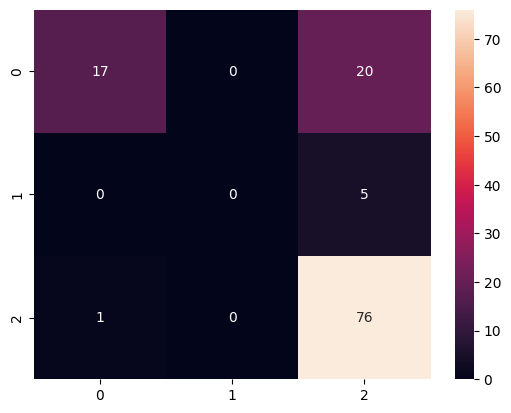

In [41]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
cmt = confusion_matrix(y_train, pred_train)
sns.heatmap(cmt, annot=True)

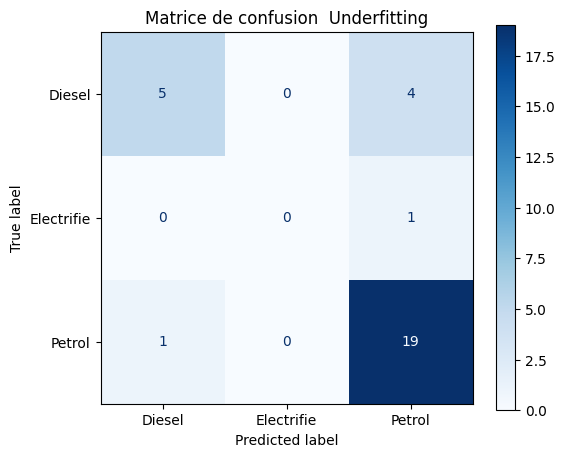

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_estimator(underfit_model, X_test_final, y_test, cmap="Blues", ax=ax)

plt.title("Matrice de confusion  Underfitting")
plt.show()

## Diagnostic du sous-apprentissage

- Accuracy train est sensiblement egal a accuracy test qui est autour de 0.65 : le modèle ne fait guère mieux que de toujours
  prédire la classe majoritaire (Petrol), aussi bien sur les données qu'il a vues que sur
  des données nouvelles.
- Le F1-macro (qui donne le même poids à chaque classe) chute à environ 0.26 : Diesel et
  Electrifie ne sont jamais prédits.
- Les probabilités prédites sont quasiment constantes quelle que soit l'observation : le
  modèle a un biais très élevé, il est trop simple (trop peu de variables informatives,
  trop de lissage) pour capturer la structure des données, même sur le train.